After filtering for Mstar ≤ 2.0 M☉: 944 data points
After dropping NaN in required columns: 578 data points

TRIPLE POWER LAW FIT WITH ALL THREE VARIABLES
Using 578 valid data points for fitting
Filtered out 0 points with Mstar <= 0
[[Model]]
    Model(triple_power_law)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 578
    # variables        = 3
    chi-square         = 169.364603
    reduced chi-square = 0.29454713
    Akaike info crit   = -703.506598
    Bayesian info crit = -690.427876
    R-squared          = 0.17038413
[[Variables]]
    log_amplitude: -5.62291174 +/- 0.31141239 (5.54%) (init = -7)
    age_exponent:  -0.41111783 +/- 0.04746726 (11.55%) (init = -1)
    mass_exponent:  1.13654862 +/- 0.11106563 (9.77%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(log_amplitude, age_exponent)  = -0.9963
    C(log_amplitude, mass_exponent) = +0.5835
    C(age_exponent, mass_exponent)  = -0.5473

BEST-

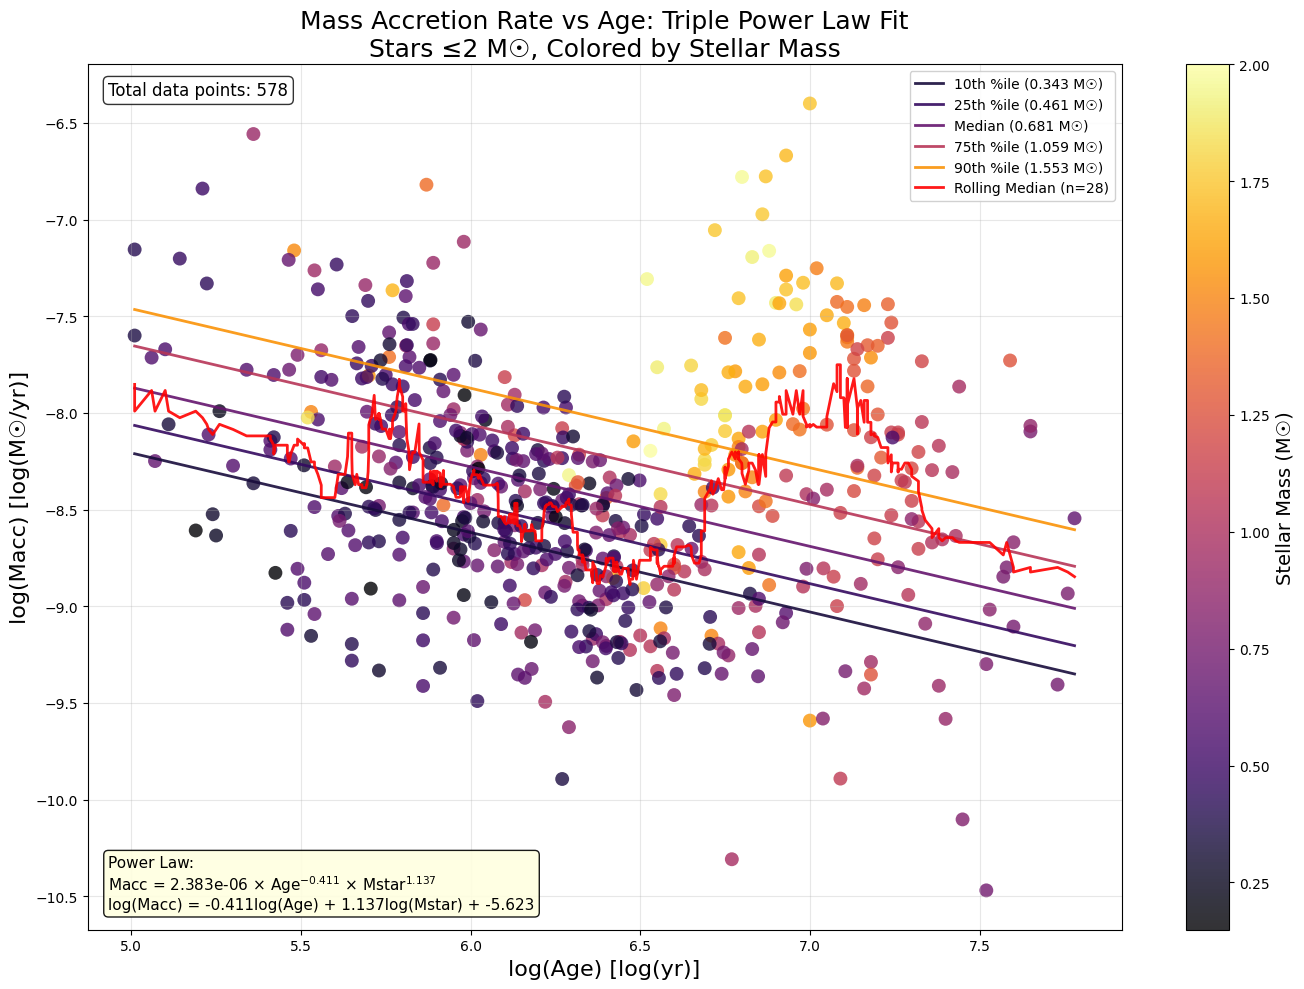

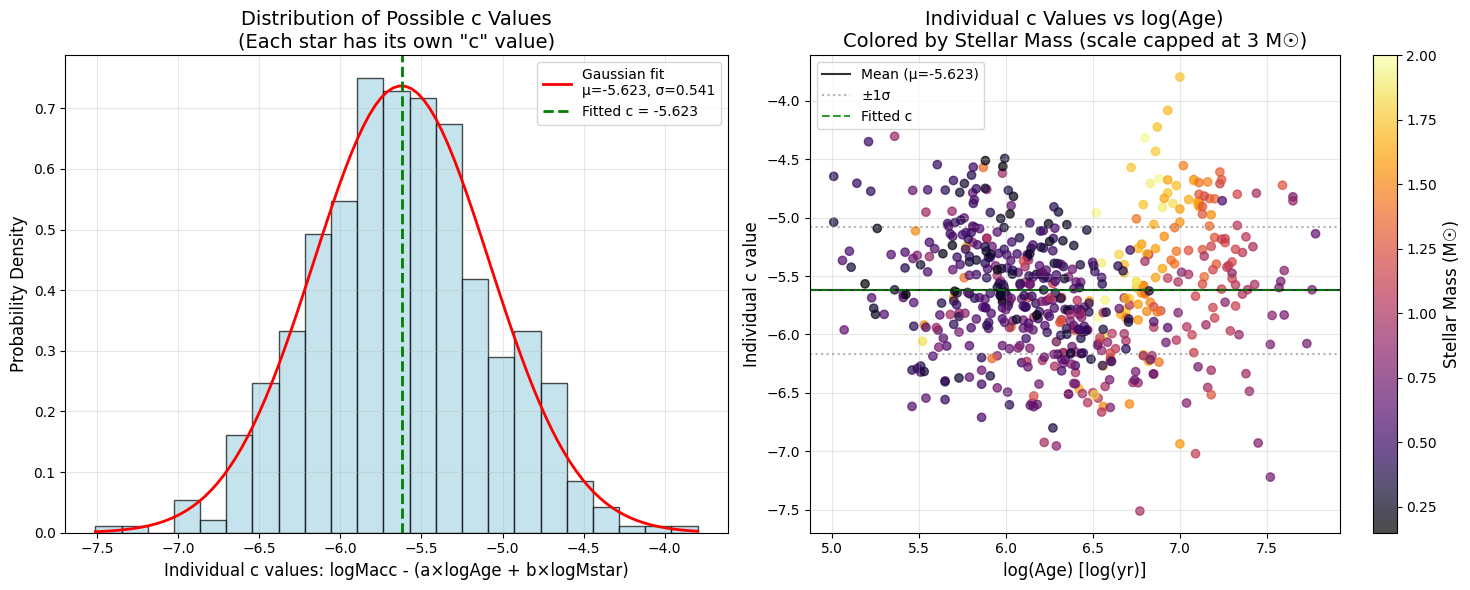

In [2]:
from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
import lmfit
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

# Load data
file_path = 'compilation_Venuti_2024_Serna_2021.csv'
df = pd.read_csv(file_path)

# FILTER FOR STARS ≤2 SOLAR MASSES
df = df[df['Mstar'] <= 2.0]
print(f"After filtering for Mstar ≤ 2.0 M☉: {len(df)} data points")

# dropna to drop rows with missing data
df = df.dropna(subset=['logAge', 'Mstar', 'logMacc'])
print(f"After dropping NaN in required columns: {len(df)} data points")

# Convert to linear space for power law fitting
df['Age_linear'] = 10**df['logAge']  # Age in years
df['Macc_linear'] = 10**df['logMacc']  # Macc in Solar Masses/yr

#Convert to log space for power law fitting
df['logMstar'] = np.log10(df['Mstar']) #Mstar in Solar Masses

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# ============================================================================
# TRIPLE POWER LAW FIT (using all three variables: Age, Mstar, Macc)
# ============================================================================
print("\n" + "="*60)
print("TRIPLE POWER LAW FIT WITH ALL THREE VARIABLES")
print("="*60)

def triple_power_law(log_age, log_mstar, log_amplitude, age_exponent, mass_exponent):
    """
    Power law model incorporating all three variables:
    log(Macc) = log_amplitude + age_exponent*log(Age) + mass_exponent*log(Mstar)
    Corresponding equation: Macc = 10^(log_amplitude) * Age^(age_exponent) * Mstar^(mass_exponent)
    """
    return log_amplitude + age_exponent * log_age + mass_exponent * log_mstar

# Create the model and specify independent variables
model_triple = lmfit.Model(triple_power_law, independent_vars=['log_age', 'log_mstar'])

# Set initial parameters with reasonable bounds
params = model_triple.make_params()
params.add('log_amplitude', value=-7, min=-12, max=5)
params.add('age_exponent', value=-1.0, min=-30.0, max=30.0)
params.add('mass_exponent', value=1.0, min=-30.0, max=30.0)

# Initialize variables
amp_linear = log_amp = age_exp = mass_exp = None
result_triple = None

try:
    # Ensure we're using numpy arrays for fitting
    log_age_data = np.array(df['logAge'].values, dtype=float)
    log_mstar_data = np.array(df['logMstar'].values, dtype=float)
    log_macc_data = np.array(df['logMacc'].values, dtype=float)
    
    # FIX: Remove any zeros or negative values from ORIGINAL Mstar, not logMstar
    valid_mask = (df['Mstar'].values > 0)  # Filter on original linear values
    
    log_age_data = log_age_data[valid_mask]
    log_mstar_data = log_mstar_data[valid_mask]
    log_macc_data = log_macc_data[valid_mask]
    
    print(f"Using {len(log_age_data)} valid data points for fitting")
    print(f"Filtered out {len(df) - len(log_age_data)} points with Mstar <= 0")
    
    # Fit the triple power law model
    result_triple = model_triple.fit(log_macc_data, params, log_age=log_age_data, log_mstar=log_mstar_data)
    
    print(result_triple.fit_report())
    
    # Extract best-fit parameters
    log_amp = result_triple.params['log_amplitude'].value
    age_exp = result_triple.params['age_exponent'].value
    mass_exp = result_triple.params['mass_exponent'].value
    
    # Convert back to linear amplitude for interpretation
    amp_linear = 10**log_amp
    
    print(f"\nBEST-FIT TRIPLE POWER LAW IN LOG SPACE:")
    print(f"logMacc = {log_amp:.3f} + {age_exp:.3f}×logAge + {mass_exp:.3f}×log(Mstar)")
    print(f"Which corresponds to:")
    print(f"Macc = {amp_linear:.3e} × Age^{age_exp:.3f} × Mstar^{mass_exp:.3f}")
    
except Exception as e:
    print(f"Triple power law analysis failed: {e}")
    import traceback
    traceback.print_exc()

if result_triple is not None:
    print(f"amp_linear: {amp_linear}")
    print(f"age_exp: {age_exp}") 
    print(f"mass_exp: {mass_exp}")
    print(f"log_amp: {log_amp}")
else:
    print("Triple power law fit failed - skipping debug prints")

# ============================================================================
# PLOTTING ALL RESULTS ON SINGLE GRAPH
# ============================================================================

# Set up color scaling
vmax = 2.0 
vmin = df['Mstar'].min()

# Plot all data points colored by stellar mass with stretched color scale
scatter = ax.scatter(df['logAge'], df['logMacc'], 
                    c=df['Mstar'],
                    cmap='inferno',
                    vmin=vmin, vmax=vmax,  # Stretched color scale
                    marker='o', 
                    edgecolors='none',
                    alpha=0.8, 
                    s=100)

# Add colorbar to show the Mstar scale
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Stellar Mass (M☉)', fontsize=14)

# Ensure mstar_custom is not used if commented out
if 'mstar_custom' in locals():
    del mstar_custom

# Calculate percentile masses for additional fit lines
if result_triple is not None:
    mstar_10 = df['Mstar'].quantile(0.10)
    mstar_25 = df['Mstar'].quantile(0.25)
    mstar_median = df['Mstar'].quantile(0.50)
    mstar_75 = df['Mstar'].quantile(0.75)
    mstar_90 = df['Mstar'].quantile(0.90)
    # mstar_custom = 3.5  # Example custom mass value for additional fit line
    
    print(f"\nStellar mass percentiles for visualization:")
    print(f"10th percentile: {mstar_10:.3f} M☉")
    print(f"25th percentile: {mstar_25:.3f} M☉")
    print(f"Median: {mstar_median:.3f} M☉")
    print(f"75th percentile: {mstar_75:.3f} M☉")
    print(f"90th percentile: {mstar_90:.3f} M☉")
    if 'mstar_custom' in locals():
        print(f"Custom stellar mass for fit line: {mstar_custom:.3f} M☉")
    
    # Generate fit line for all mass percentiles
    x_fit_log = np.linspace(df['logAge'].min(), df['logAge'].max(), 100)
    age_fit_linear = 10**x_fit_log
    
    # Calculate triple power law predictions for each mass percentile
    mstar_percentiles = [mstar_10, mstar_25, mstar_median, mstar_75, mstar_90]
    labels = ['10th %ile', '25th %ile', 'Median', '75th %ile', '90th %ile']
    
    # Add custom mass if uncommented
    if 'mstar_custom' in locals():
        mstar_percentiles.append(mstar_custom)
        labels.append('Custom (3.5 M☉)')
    
    # Get colors from the colormap for each mass
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.inferno
    colors = [cmap(norm(mstar)) for mstar in mstar_percentiles]
    
    # Plot all fit lines with colors matching the colormap
    for i, (mstar, color, label) in enumerate(zip(mstar_percentiles, colors, labels)):
        macc_fit = amp_linear * np.power(age_fit_linear, age_exp) * np.power(mstar, mass_exp)
        
        # Safety check for log10
        if np.any(macc_fit <= 0):
            macc_fit = np.maximum(macc_fit, 1e-10)
        
        ax.plot(x_fit_log, np.log10(macc_fit), color=color, linewidth=2, 
                linestyle='-', alpha=0.9, label=f'{label} ({mstar:.3f} M☉)')
        
        print(f"macc_fit range - {label}: {macc_fit.min():.3e} to {macc_fit.max():.3e}")

# Rolling median calculation and plotting
# Sort data by age for proper rolling calculation
df_sorted = df.sort_values('logAge').copy()

# Calculate rolling median
window_size = int(len(df) * 0.05)
if window_size < 5:
    window_size = 5 
df_sorted['rolling_median_logMacc'] = df_sorted['logMacc'].rolling(window=window_size, center=True, min_periods=1).median()

# Plot rolling median
ax.plot(df_sorted['logAge'], df_sorted['rolling_median_logMacc'], 
        color='red', linewidth=2, linestyle='-', alpha=0.9,
        label=f'Rolling Median (n={window_size})')

print(f"\nRolling median calculated with window size: {window_size} points")

# Configure plot appearance
ax.set_xlabel('log(Age) [log(yr)]', fontsize=16)
ax.set_ylabel('log(Macc) [log(M☉/yr)]', fontsize=16)
ax.set_title('Mass Accretion Rate vs Age: Triple Power Law Fit\nStars ≤2 M☉, Colored by Stellar Mass', fontsize=18)
ax.grid(True, alpha=0.3)

# Add statistics to plot - TOP LEFT
stats_text = f'Total data points: {len(df)}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ADD EQUATIONS - BOTTOM LEFT
if result_triple is not None:
    # Main power law equation
    eq_text_main = (f'Power Law:\nMacc = {amp_linear:.3e} × Age$^{{{age_exp:.3f}}}$ × Mstar$^{{{mass_exp:.3f}}}$\n'
                   f'log(Macc) = {age_exp:.3f}log(Age) + {mass_exp:.3f}log(Mstar) + {log_amp:.3f}')
    
    ax.text(0.02, 0.02, eq_text_main, transform=ax.transAxes,
            verticalalignment='bottom', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# LEGEND FOR FIT LINES - TOP RIGHT
if result_triple is not None:
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

plt.tight_layout()

# ============================================================================
# C VALUES AS PROBABILITY DISTRIBUTION
# ============================================================================
if result_triple is not None:
    print("\n" + "="*60)
    print("PROBABILISTIC ANALYSIS: DISTRIBUTION OF POSSIBLE c VALUES")
    print("="*60)
    
    # Calculate distribution of possible c values: logMacc - (a×logAge + b×logMstar)
    individual_c_values = df['logMacc'] - (age_exp * df['logAge'] + mass_exp * df['logMstar'])
    
    print(f"Individual c values statistics:")
    print(f"  Mean (µ): {individual_c_values.mean():.3f}")
    print(f"  Std Dev (σ): {individual_c_values.std():.3f}")
    print(f"  Min c value: {individual_c_values.min():.3f}")
    print(f"  Max c value: {individual_c_values.max():.3f}")
    print(f"  Original fitted c: {log_amp:.3f}")
    
    # Fit Gaussian to the distribution of individual c values
    from scipy.stats import norm
    mu, sigma = norm.fit(individual_c_values)
    
    print(f"\nGaussian fit to individual c values:")
    print(f"  µ (mean): {mu:.3f}")
    print(f"  σ (std dev): {sigma:.3f}")
    print(f"  Difference from fitted c: {mu - log_amp:.3f}")
    
    # Create visualization of the c-value distribution
    fig_cdist, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Histogram with Gaussian fit
    n, bins, patches = ax1.hist(individual_c_values, bins='auto', density=True, alpha=0.7, 
                               color='lightblue', edgecolor='black')
    
    # Plot the fitted Gaussian
    x = np.linspace(individual_c_values.min(), individual_c_values.max(), 100)
    y = norm.pdf(x, mu, sigma)
    ax1.plot(x, y, 'r-', linewidth=2, label=f'Gaussian fit\nµ={mu:.3f}, σ={sigma:.3f}')
    
    # Mark the original fitted c value
    ax1.axvline(x=log_amp, color='green', linestyle='--', linewidth=2, 
                label=f'Fitted c = {log_amp:.3f}')
    
    ax1.set_xlabel('Individual c values: logMacc - (a×logAge + b×logMstar)', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.set_title('Distribution of Possible c Values\n(Each star has its own "c" value)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
   # Plot 2: Individual c values vs logAge - checks for age dependence
    scatter2 = ax2.scatter(df['logAge'], individual_c_values, 
                      c=df['Mstar'], cmap='inferno', 
                      vmin=vmin, vmax=vmax, alpha=0.7)

    ax2.axhline(y=mu, color='black', linestyle='-', alpha=0.8, label=f'Mean (µ={mu:.3f})')
    ax2.axhline(y=mu + sigma, color='gray', linestyle=':', alpha=0.6, label=f'±1σ')
    ax2.axhline(y=mu - sigma, color='gray', linestyle=':', alpha=0.6)
    ax2.axhline(y=log_amp, color='green', linestyle='--', alpha=0.8, label=f'Fitted c')

    ax2.set_xlabel('log(Age) [log(yr)]', fontsize=12)
    ax2.set_ylabel('Individual c value', fontsize=12)
    ax2.set_title('Individual c Values vs log(Age)\nColored by Stellar Mass (scale capped at 3 M☉)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Add colorbar for stellar mass
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Stellar Mass (M☉)', fontsize=12)

plt.tight_layout()
    
# ============================================================================
# PROBABILISTIC INTERPRETATION AND PREDICTIONS
# ============================================================================
print(f"\n" + "="*50)
print("C AS PROBABILITY DISTRIBUTION: INTERPRETATION")
print("="*50)
    
print(f"\nThe C Distribution model states:")
print(f"logMacc = {age_exp:.3f}×logAge + {mass_exp:.3f}×logMstar + c")
print(f"where c ~ Normal(µ = {mu:.3f}, σ = {sigma:.3f})")
    
print(f"\n Understanding the model:")
print(f"1. Each star has its own c value due to physics not captured by age & mass")
print(f"2. The spread (σ = {sigma:.3f}) shows variation in accretion rates")
print(f"3. 68% of stars have c values within ±{sigma:.3f} of the mean")
print(f"4. Our original fit found the average c = {log_amp:.3f}")

# How much of the total variance is explained vs unexplained
total_variance = df['logMacc'].var()
explained_variance = (age_exp**2 * df['logAge'].var() + 
                      mass_exp**2 * df['logMstar'].var() + 
                      2 * age_exp * mass_exp * df['logAge'].cov(df['logMstar']))
fraction_explained = explained_variance / total_variance
    
print(f"\nVariance decomposition:")
print(f"  Total variance in logMacc: {total_variance:.3f}")
print(f"  Variance explained by age & mass: {explained_variance:.3f} ({fraction_explained*100:.3f}%)")
print(f"  Unexplained variance (σ²): {sigma**2:.3f} ({(sigma**2/total_variance)*100:.3f}%)")

# FILE 1 - contains power law coefficients, uncertainty parameters, Data ranges for realistic synthetic generation
np.save('power_law_model.npy', {
    'log_amp': log_amp,
    'age_exp': age_exp, 
    'mass_exp': mass_exp,
    'mu': mu,
    'sigma': sigma,
    'age_range': [df['logAge'].min(), df['logAge'].max()],
    'mass_range': [df['Mstar'].min(), df['Mstar'].max()],
    'logMstar_range': [df['logMstar'].min(), df['logMstar'].max()],
    'original_fit_params': [log_amp, age_exp, mass_exp, mu, sigma]
})
print("✓ Power law model parameters saved to 'power_law_model.npy'")

# FILE 2 - stellar accretion data - contains original data, calculated processed columns (inlcuding linear data) and individual c values for each star
df['c_value'] = df['logMacc'] - (age_exp * df['logAge'] + mass_exp * df['logMstar'])
df.to_csv('stellar_accretion_data.csv', index=False)
print("✓ Stellar accretion data with residuals saved to 'stellar_accretion_data.csv'")

# ============================================================================
# CREATE COMBINED PDF WITH TEXT AND IMAGE
# ============================================================================

# Define PDF filename
PDF_FILENAME = 'CapstoneReport_Nov17_Tanay.pdf'

def create_combined_pdf():
    try:
        with PdfPages(PDF_FILENAME) as pdf:
            # First page: Text results
            fig_text, ax_text = plt.subplots(figsize=(8.5, 11))  # Letter size
            ax_text.axis('off')  # Hide axes
            
            # Prepare text content
            text_content = []
            text_content.append("Capstone Project Report")
            text_content.append(f"By: Tanay Ayiliath")
            text_content.append("TRIPLE POWER LAW FIT ANALYSIS RESULTS")
            text_content.append("=" * 50)
            text_content.append("")
            text_content.append("DATA STATISTICS:")
            text_content.append(f"Total data points: {len(df)}")
            text_content.append(f"logMacc range: {df['logMacc'].min():.3f} to {df['logMacc'].max():.3f}")
            text_content.append(f"logAge range: {df['logAge'].min():.3f} to {df['logAge'].max():.3f}")
            text_content.append(f"Mstar range: {df['Mstar'].min():.3f} to {df['Mstar'].max():.3f} Solar Masses")
            text_content.append("")
            text_content.append("CORRELATIONS:")
            text_content.append(f"logAge vs logMacc: {df['logAge'].corr(df['logMacc']):.3f}")
            text_content.append(f"logMstar vs logMacc: {df['logMstar'].corr(df['logMacc']):.3f}")
            text_content.append(f"logAge vs logMstar: {df['logAge'].corr(df['logMstar']):.3f}")
            text_content.append("")
            
            if result_triple is not None:
                text_content.append("TRIPLE POWER LAW FIT RESULTS:")
                text_content.append(f"log(Macc) = {log_amp:.3f} + {age_exp:.3f}×logAge + {mass_exp:.3f}×log(Mstar)")
                text_content.append(f"Macc = {amp_linear:.3e} × Age^{age_exp:.3f} × Mstar^{mass_exp:.3f}")
                text_content.append("")
                text_content.append("INTERPRETATION:")
                if age_exp < 0:
                    text_content.append("→ Mass accretion decreases with age (expected)")
                else:
                    text_content.append("→ UNEXPECTED: mass accretion increases with age")
                if mass_exp > 0:
                    text_content.append("→ More massive stars have higher accretion rates (expected)")
                else:
                    text_content.append("→ UNEXPECTED: less massive stars have higher accretion rates")
                
                # Add probabilistic analysis results if available
                if 'individual_c_values' in globals():
                    text_content.append("")
                    text_content.append("PROBABILISTIC ANALYSIS:")
                    text_content.append(f"Individual c values distribution: c ~ N(μ={mu:.3f}, σ={sigma:.3f})")
                    text_content.append(f"→ Intrinsic scatter in accretion physics: σ = {sigma:.3f}")
                    text_content.append(f"→ 68% of stars have c values within ±{sigma:.3f} of mean")
                    if 'fraction_explained' in globals():
                        text_content.append(f"→ Age & mass explain {fraction_explained*100:.3f}% of variance")
                        text_content.append(f"→ Unexplained variance: {(sigma**2/total_variance)*100:.3f}%")
            
            # Add text to page
            ax_text.text(0.05, 0.95, '\n'.join(text_content), 
                        transform=ax_text.transAxes, fontsize=10, 
                        verticalalignment='top', fontfamily='monospace')
            
            # Date and time in bottom right corner
            from datetime import datetime
            current_time = datetime.now().strftime("%d-%m-%Y %H:%M:%S")
            ax_text.text(0.95, 0.02, f"Generated: {current_time}", 
                        transform=ax_text.transAxes, fontsize=8,
                        verticalalignment='bottom', horizontalalignment='right',
                        style='italic', alpha=0.7)
            
            pdf.savefig(fig_text, bbox_inches='tight')
            plt.close(fig_text)
            
            # Second page: The main accretion plot
            pdf.savefig(fig, bbox_inches='tight')
            
            # Third page: Probabilistic analysis plots
            if result_triple is not None and 'fig_cdist' in globals() and fig_cdist is not None:
                pdf.savefig(fig_cdist, bbox_inches='tight')
            
            # Add metadata
            d = pdf.infodict()
            d['Title'] = 'Triple Power Law Fit Analysis with Probabilistic Interpretation'
            d['Author'] = 'Tanay Ayiliath'
            d['Subject'] = 'Mass Accretion Rate Analysis with Uncertainty Quantification'
            
        print(f"Combined PDF report successfully saved as: {PDF_FILENAME}")
        
    except Exception as e:
        print(f"Error saving PDF: {e}")
        import traceback
        traceback.print_exc()

# ADDED: Conditional PDF creation
def ask_save_pdf():
    """Ask user whether to save PDF report"""
    response = input("\nSave PDF report? (y/n): ").strip().lower()
    return response in ['y', 'yes', '1']

# Conditionally create the combined PDF
if ask_save_pdf():
    create_combined_pdf()
else:
    print("PDF report skipped")

# ============================================================================
# COMPREHENSIVE SUMMARY
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print(f"\nDATA STATISTICS:")
print(f"Total data points: {len(df)}")
print(f"logMacc range: {df['logMacc'].min():.3f} to {df['logMacc'].max():.3f}")
print(f"logAge range: {df['logAge'].min():.3f} to {df['logAge'].max():.3f}")
print(f"Mstar range: {df['Mstar'].min():.3f} to {df['Mstar'].max():.3f} Solar Masses")
print(f"logMstar range: {df['logMstar'].min():.3f} to {df['logMstar'].max():.3f} Solar Masses")

print(f"\nCORRELATIONS:")
print(f"logAge vs logMacc: {df['logAge'].corr(df['logMacc']):.3f}")
print(f"logMstar vs logMacc: {df['logMstar'].corr(df['logMacc']):.3f}")
print(f"logAge vs logMstar: {df['logAge'].corr(df['logMstar']):.3f}")

print(f"\nINTERPRETATION:")
if result_triple is not None:
    print(f"TRIPLE POWER LAW: log(Macc) = {age_exp:.3f}log(Age) + {mass_exp:.3f}log(Mstar) + {log_amp:.3f}")
    if age_exp < 0:
        print(f"  → Mass accretion decreases with age (expected)")
    else:
        print(f"  → UNEXPECTED: mass accretion increases with age")
        
    if mass_exp > 0:
        print(f"  → More massive stars have higher accretion rates (expected)")
    else:
        print(f"  → UNEXPECTED: less massive stars have higher accretion rates")